In [ ]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

### Fetch the list of supported coins

In [24]:
def fetch_supported_coins():
    url = "https://api.coingecko.com/api/v3/coins/list"
    response = requests.get(url)
    if response.status_code == 200:
        data = json.loads(response.text)
        return data
    else:
        return None

if __name__ == "__main__":
    supported_coins = fetch_supported_coins()
    
    if supported_coins:
        
        # print("List of supported coins:")
        # for i, coin in enumerate(supported_coins):
        #     print(f"{i+1}. ID: {coin['id']}, Name: {coin['name']}, Symbol: {coin['symbol']}")
            
        print("List of top 100 supported coins:")
        for i, coin in enumerate(supported_coins[:100]):  # Limit to top 100 coins
            print(f"{i+1}. ID: {coin['id']}, Name: {coin['name']}, Symbol: {coin['symbol']}")
            
            if (i + 1) % 10 == 0:  # After every 10 coins, sleep for 6 seconds
                # print("Sleeping for 6 seconds to respect rate limit...")
                time.sleep(6)
    else:
        print("Failed to fetch the list of supported coins.")

List of top 100 supported coins:
1. ID: 01coin, Name: 01coin, Symbol: zoc
2. ID: 0chain, Name: Zus, Symbol: zcn
3. ID: 0-knowledge-network, Name: 0 Knowledge Network, Symbol: 0kn
4. ID: 0vix-protocol, Name: 0VIX Protocol, Symbol: vix
5. ID: 0x, Name: 0x Protocol, Symbol: zrx
6. ID: 0x0-ai-ai-smart-contract, Name: 0x0.ai: AI Smart Contract, Symbol: 0x0
7. ID: 0x1-tools-ai-multi-tool, Name: 0x1.tools: AI Multi-tool, Symbol: 0x1
8. ID: 0xauto-io-contract-auto-deployer, Name: 0xAuto.io : Contract Auto Deployer, Symbol: 0xa
9. ID: 0xcoco, Name: 0xCoco, Symbol: coco
10. ID: 0xdao, Name: 0xDAO, Symbol: oxd
11. ID: 0xdao-v2, Name: 0xDAO V2, Symbol: oxd v2
12. ID: 0xfriend, Name: 0xFriend, Symbol: 0xf
13. ID: 0xgasless, Name: 0xGasless, Symbol: 0xgas
14. ID: 0xmonero, Name: 0xMonero, Symbol: 0xmr
15. ID: 0xs, Name: 0xS, Symbol: $0xs
16. ID: 0xshield, Name: 0xShield, Symbol: shield
17. ID: 0xsniper, Name: 0xSniper, Symbol: 0xs
18. ID: 12ships, Name: 12Ships, Symbol: tshp
19. ID: 1art, Name: OneA

### Fetch Realtime Price

In [25]:
def fetch_realtime_price(crypto_id):
    url = f"https://api.coingecko.com/api/v3/simple/price?ids={crypto_id}&vs_currencies=usd"
    response = requests.get(url)
    data = json.loads(response.text)
    return data[crypto_id]['usd']

def fetch_historical_price(crypto_id, date):
    url = f"https://api.coingecko.com/api/v3/coins/{crypto_id}/history?date={date}"
    response = requests.get(url)
    data = json.loads(response.text)
    return data['market_data']['current_price']['usd']

if __name__ == "__main__":
    # Fetch real-time price for Bitcoin
    realtime_price = fetch_realtime_price("bitcoin")
    print(f"Real-time price of Bitcoin: ${realtime_price}")

    # Fetch historical price for Bitcoin on a specific date (format: dd-mm-yyyy)
    historical_price = fetch_historical_price("bitcoin", "01-01-2021")
    print(f"Historical price of Bitcoin on 01-01-2021: ${historical_price}")


Real-time price of Bitcoin: $25728
Historical price of Bitcoin on 01-01-2021: $29022.41839530417


### Fetch historical price (daily)

Real-time price of Bitcoin: $25728
Fetched price for 01-01-2023: $16540.693624776803
Fetched price for 02-01-2023: $16615.969318012816
Fetched price for 03-01-2023: $16674.342536301097
Fetched price for 04-01-2023: $16677.646185850346
Fetched price for 05-01-2023: $16855.1747387671
Fetched price for 06-01-2023: $16832.098988497855
Fetched price for 07-01-2023: $16960.23206247515
Fetched price for 08-01-2023: $16950.861521853905
Fetched price for 09-01-2023: $17074.61539572674
Fetched price for 10-01-2023: $17194.90932945318
Fetched price for 11-01-2023: $17436.90232978116
Fetched price for 12-01-2023: $17996.832553741606
Fetched price for 13-01-2023: $18866.810330617045
Fetched price for 14-01-2023: $19941.780543296303
Fetched price for 15-01-2023: $21019.20661402266
Fetched price for 16-01-2023: $20853.230569490253
Fetched price for 17-01-2023: $21175.33773662521
Fetched price for 18-01-2023: $21156.78393116713
Fetched price for 19-01-2023: $20726.844969426445
Fetched price for 20-01-

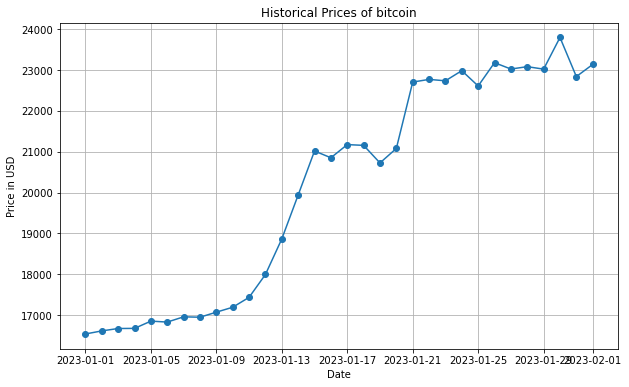

In [26]:
def fetch_all_historical_prices(crypto_id, start_date, end_date):
    current_date = datetime.strptime(start_date, "%d-%m-%Y")
    end_date = datetime.strptime(end_date, "%d-%m-%Y")
    historical_prices = {}

    while current_date <= end_date:
        formatted_date = current_date.strftime("%d-%m-%Y")
        try:
            price = fetch_historical_price(crypto_id, formatted_date)
            historical_prices[formatted_date] = price
            print(f"Fetched price for {formatted_date}: ${price}")
        except Exception as e:
            print(f"Failed to fetch price for {formatted_date}: {e}")

        current_date += timedelta(days=1)
        
        # Sleep for 6 seconds to limit to 10 calls per minute (for using public api)
        time.sleep(6)

    return historical_prices

if __name__ == "__main__":
    # Fetch real-time price for Bitcoin
    realtime_price = fetch_realtime_price("bitcoin")
    print(f"Real-time price of Bitcoin: ${realtime_price}")

    # Change here for crypto id and date range
    historical_prices = fetch_all_historical_prices("bitcoin", "01-01-2023", "01-02-2023")

    df = pd.DataFrame(list(historical_prices.items()), columns=['Date', 'Price'])
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
    df.set_index('Date', inplace=True)

    # Plot the data
    plt.figure(figsize=(10, 6))
    plt.plot(df.index, df['Price'], marker='o', linestyle='-')
    plt.title('Historical Prices of bitcoin')
    plt.xlabel('Date')
    plt.ylabel('Price in USD')
    plt.grid(True)
    plt.show()

#### Hourly (hourly data for the past 90 days)

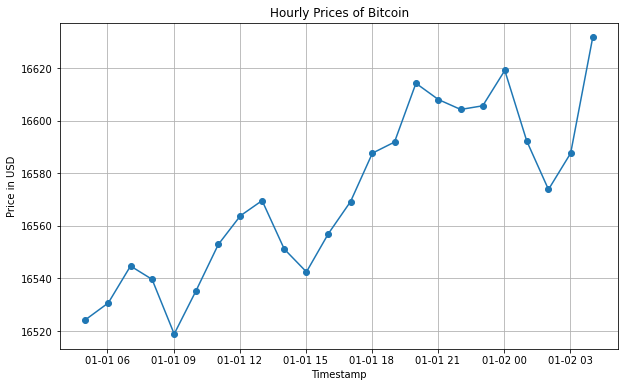

In [22]:
def fetch_hourly_prices(crypto_id, from_timestamp, to_timestamp):
    url = f"https://api.coingecko.com/api/v3/coins/{crypto_id}/market_chart/range?vs_currency=usd&from={from_timestamp}&to={to_timestamp}"
    response = requests.get(url)
    data = json.loads(response.text)
    hourly_prices = data['prices']
    return hourly_prices

if __name__ == "__main__":

    # Define the date range for fetching hourly prices (Unix timestamps)
    from_date = "01-01-2023"
    to_date = "02-01-2023"
    from_timestamp = int(time.mktime(datetime.strptime(from_date, "%d-%m-%Y").timetuple()))
    to_timestamp = int(time.mktime(datetime.strptime(to_date, "%d-%m-%Y").timetuple()))

    # Fetch hourly prices for Bitcoin within the date range
    hourly_prices = fetch_hourly_prices("bitcoin", from_timestamp, to_timestamp)

    # Convert the hourly prices to a DataFrame
    df = pd.DataFrame(hourly_prices, columns=['Timestamp', 'Price'])
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='ms')
    df.set_index('Timestamp', inplace=True)

    # Plot the data
    plt.figure(figsize=(10, 6))
    plt.plot(df.index, df['Price'], marker='o', linestyle='-')
    plt.title('Hourly Prices of Bitcoin')
    plt.xlabel('Timestamp')
    plt.ylabel('Price in USD')
    plt.grid(True)
    plt.show()


#### Minute level (minute-level data for the past 30 days)

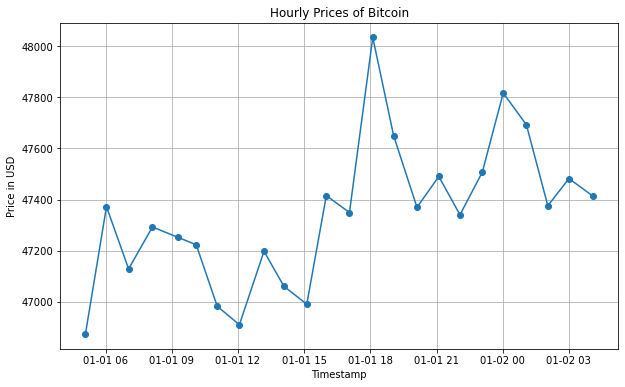

In [23]:
def fetch_hourly_prices(crypto_id, from_timestamp, to_timestamp):
    url = f"https://api.coingecko.com/api/v3/coins/{crypto_id}/market_chart/range?vs_currency=usd&from={from_timestamp}&to={to_timestamp}"
    response = requests.get(url)
    data = json.loads(response.text)
    hourly_prices = data['prices']
    return hourly_prices

if __name__ == "__main__":

    # Define the date range for fetching hourly prices (Unix timestamps)
    from_date = "01-01-2022"
    to_date = "02-01-2022"
    from_timestamp = int(time.mktime(datetime.strptime(from_date, "%d-%m-%Y").timetuple()))
    to_timestamp = int(time.mktime(datetime.strptime(to_date, "%d-%m-%Y").timetuple()))

    # Fetch hourly prices for Bitcoin within the date range
    hourly_prices = fetch_hourly_prices("bitcoin", from_timestamp, to_timestamp)

    # Convert the hourly prices to a DataFrame
    df = pd.DataFrame(hourly_prices, columns=['Timestamp', 'Price'])
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='ms')
    df.set_index('Timestamp', inplace=True)

    # Plot the data
    plt.figure(figsize=(10, 6))
    plt.plot(df.index, df['Price'], marker='o', linestyle='-')
    plt.title('Hourly Prices of Bitcoin')
    plt.xlabel('Timestamp')
    plt.ylabel('Price in USD')
    plt.grid(True)
    plt.show()

In [ ]:
def get_developer_metrics(coin_id):
    """
    Fetch developer metrics for a given cryptocurrency from CoinGecko.
    
    Parameters:
    - coin_id (str): The ID of the cryptocurrency on CoinGecko.
    
    Returns:
    - dict: A dictionary containing developer data.
    """
    base_url = "https://api.coingecko.com/api/v3/coins/"
    response = requests.get(base_url + coin_id)
    
    if response.status_code == 200:
        data = response.json()
        developer_data = data.get('developer_data', {})
        return developer_data
    else:
        print(f"Error {response.status_code}: Unable to fetch data.")
        return None

In [ ]:
coin_id = "bitcoin"  # You can replace this with the ID of any other cryptocurrency.
developer_metrics = get_developer_metrics(coin_id)

if developer_metrics:
    print("Developer Metrics for", coin_id)
    print("-" * 30)
    print("GitHub Stars:", developer_metrics.get('stars', 'N/A'))
    print("GitHub Forks:", developer_metrics.get('forks', 'N/A'))
    print("Subscribers:", developer_metrics.get('subscribers', 'N/A'))
    print("Issues:", developer_metrics.get('issues', 'N/A'))
    print("Pull Requests Merged:", developer_metrics.get('pull_requests_merged', 'N/A'))
    print("Pull Request Contributors:", developer_metrics.get('pull_request_contributors', 'N/A'))
    print("Code Additions/Deletions (Last 4 Weeks):", developer_metrics.get('code_additions_deletions_4_weeks', 'N/A'))
    print("Commit Count (Last 4 Weeks):", developer_metrics.get('commit_count_4_weeks', 'N/A'))
else:
    print("Failed to retrieve developer metrics.")